In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

Importation des données

In [40]:
%load_ext autoreload
%autoreload 2 

#pour pas avoir à reload à chaque fois qu'on mofifie une fonction dans un autre fichier

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [348]:
df = pd.read_csv(r"..\data\en.openfoodfacts.org.products.csv.gz", sep="\t", encoding='utf-8', nrows=10000)

C:\Users\julie\AppData\Local\Temp\ipykernel_39628\3062298247.py:1: DtypeWarning: Columns (0: abbreviated_product_name, 1: packaging_text, 2: no_nutrition_data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"..\data\en.openfoodfacts.org.products.csv.gz", sep="\t", encoding='utf-8', nrows=10000)


In [349]:
df.head()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,...,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g,water_100g
0,54,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1582569031,2020-02-24T18:30:31Z,1733085204,2024-12-01T20:33:24Z,NaN,1740205422,2025-02-22T06:23:42Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,63,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1673620307,2023-01-13T14:31:47Z,1750061386,2025-06-16T08:09:46Z,bodysupport,1750061386,2025-06-16T08:09:46Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,114,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1580066482,2020-01-26T19:21:22Z,1751035658,2025-06-27T14:47:38Z,teolemon,1751035658,2025-06-27T14:47:38Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,431,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1714301712,2024-04-28T10:55:12Z,1714301721,2024-04-28T10:55:21Z,kiliweb,1714301721,2024-04-28T10:55:21Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,105,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1572117743,2019-10-26T19:22:23Z,1738073570,2025-01-28T14:12:50Z,NaN,1743653496,2025-04-03T04:11:36Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [350]:
df.shape

(10000, 211)

In [351]:
with open("colonnes.txt", "w") as f:
    for col in df.columns:
        f.write(col + "\n") ### ça créer un fichier texte avec le nom de TOUTES les colonnes du dataframe

#il y a une colomne nomée nutriscore_grade avec des valeurs de type objet (str)


In [352]:
print(df["nutriscore_grade"].dtype)

print(df["nutriscore_grade"].unique())

print(df["nutriscore_grade"].value_counts())

#on a ~ 30% de nos aliments qui ont un nutriscore connu. 
#on train sur ces 30% et on test sur les autres 70% pour prédire le nutriscore des aliments qui n'ont pas de nutriscore connu.
#puis on vérifie si les scores calculés sont cohérents avec les autres informations nutritionnelles de l'aliment avec des graphiques. Comme des boxplot pour chaque catégorie (A, B..) en fonction du sucre par exemple. 
#MAIS on peut AUSSI couper les 30% en deux parties, une pour le train et une pour le test, pour évaluer la performance de notre modèle.
#je trouve ça mieux car au moins on a nos score, on peut faire nos training curve etc .. Puis on peut ensuite appliquer le modèle sur les 70% restants pour prédire le nutriscore des aliments qui n'ont pas de nutriscore connu.

str
<StringArray>
['unknown', nan, 'c', 'a', 'not-applicable', 'e', 'd', 'b']
Length: 8, dtype: str
nutriscore_grade
unknown           8455
e                  306
not-applicable     267
d                  209
c                  190
a                  171
b                   89
Name: count, dtype: int64


Spliter les données en deux parties : une pour l'entraînement et une pour le test. Méthode HOLD OUT

In [353]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["nutriscore_grade"])   # nos variables explicatives
y = df["nutriscore_grade"]                   # ce qu'on veut prédire

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#test_size should be between 0.0 and 1.0 and represent the proportion of the dataset to include in the test split.

##la ça prend tout le jeu de données donc pas bien. 
#Il faut le faire sur les 30% des données avec nutriscore connu, donc créons un nouveau dataframe?

In [354]:
#je génère 2 nouveaux dataframes, un avec les aliments qui ont un nutriscore connu et un autre avec ceux qui n'ont pas de nutriscore connu.

# DataFrame avec les nutriscores connus (a, b, c, d, e)
scores_connus = ['a', 'b', 'c', 'd', 'e']
df_connu = df[df['nutriscore_grade'].isin(scores_connus)].copy()

# DataFrame avec le reste (unknown, not-applicable, ou NaN éventuels)
df_inconnu = df[~df['nutriscore_grade'].isin(scores_connus)].copy()

# Vérification rapide
print("Connu :", df_connu.shape)
print("Inconnu :", df_inconnu.shape)
print(df_connu['nutriscore_grade'].value_counts())
print(df_inconnu['nutriscore_grade'].value_counts(dropna=False))

Connu : (965, 211)
Inconnu : (9035, 211)
nutriscore_grade
e    306
d    209
c    190
a    171
b     89
Name: count, dtype: int64
nutriscore_grade
unknown           8455
NaN                313
not-applicable     267
Name: count, dtype: int64


In [355]:
from sklearn.model_selection import train_test_split

features = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g',
            'fiber_100g', 'proteins_100g', 'fruits-vegetables-legumes_100g',
            'fat_100g', 'carbohydrates_100g']

X = df_connu[features]  # Seules CES colonnes sont sélectionnées, tout le reste est ignoré
y = df_connu['nutriscore_grade']    

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#test_size should be between 0.0 and 1.0 and represent the proportion of the dataset to include in the test split.

PREPARATION DES DONNEES

Gérer données manquantes 

In [377]:
#Nettoyage minimal des données
percent_missing = df_connu[features].isnull().sum() * 100 / len(df_connu)
percent_missing.sort_values(ascending=False,inplace=True)

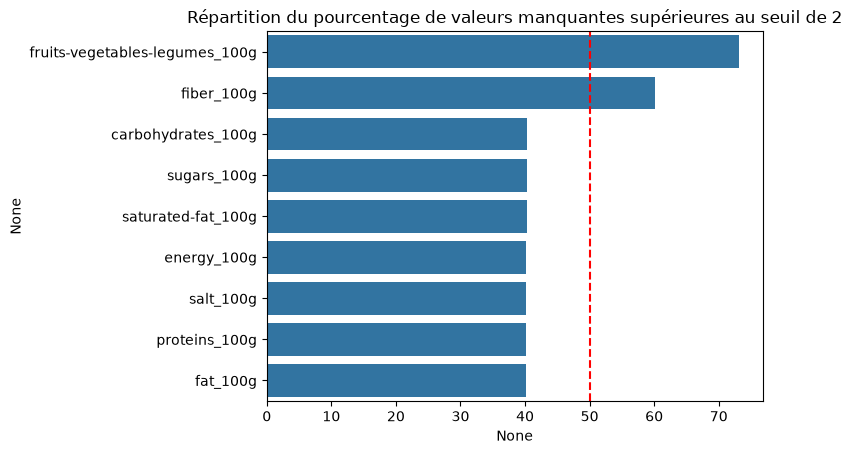

In [378]:
threshold_view = 2

filtered = percent_missing[percent_missing.values > threshold_view]
ax = sns.barplot(x = filtered, y = filtered.index, orient='h');
ax.set_title(f"Répartition du pourcentage de valeurs manquantes supérieures au seuil de {threshold_view}");

threshold = 50

ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")

In [379]:
## On retire les features avec + de 60% de valeurs manquantes

columns_to_drop = percent_missing[percent_missing.values > threshold].index
print(columns_to_drop)

df_restr_8 = df_connu[features + ['nutriscore_grade']].drop(columns=columns_to_drop)

print(df_restr_8.shape)
df_restr_8.head()

Index(['fruits-vegetables-legumes_100g', 'fiber_100g'], dtype='str')
(965, 8)


,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,proteins_100g,fat_100g,carbohydrates_100g,nutriscore_grade
12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c
13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c
14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a
18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c
19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,e


In [380]:
mask_complet = X_reduit.dropna().index
print(df_connu.loc[mask_complet, 'nutriscore_grade'].value_counts())


nutriscore_grade
e    158
c    138
d    123
a     89
b     66
Name: count, dtype: int64


In [383]:
##il y a des lignes avec des NaN dans chaque features, il faut les supprimer ! 

df_restr_8[df_restr_8.isna().sum(axis=1) >= 5]
(df_restr_8.isna().sum(axis=1) == 7).sum()


np.int64(388)

In [384]:
df_restr_8 = df_restr_8[df_restr_8.isna().sum(axis=1) != 7] ##je supprime les lignes avec 7 valeurs manquantes.

In [387]:
print(df_restr_8.shape)
df_restr_8.head()

(577, 8)


,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,proteins_100g,fat_100g,carbohydrates_100g,nutriscore_grade
840,697.100000,1.3,1.9,0.0009,6.7,6.400000,20.0,c
875,1928.500000,13.8,18.0,0.6490,6.0,28.000000,46.5,e
890,2524.000000,10.0,32.0,0.0100,8.0,48.000000,36.0,e
892,929.000000,1.2,0.6,0.8000,13.5,12.000000,11.8,a
946,1357.900028,12.7,0.0,0.0000,0.0,36.700001,0.0,d


In [362]:
#### PLUS TARD :AJOUER DES VARIABLES EXPLICATIVES SUPPLEMENTAIRES POUR AMELIORER LA PREDICTION DU NUTRISCORE

Imputation = pas besoin avec le df_restr_8. A faire peut être quand on ajoutera des features

Même chose mais en appelant les fonctions du fichier preprocess.py pour que le notebook soit plus lisible et plus clair! 

In [ ]:
from preprocess import preprocess_pipeline

mes_features = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g',
            'fiber_100g', 'proteins_100g', 'fruits-vegetables-legumes_100g',
            'fat_100g', 'carbohydrates_100g']

preprocess_9 = preprocess_pipeline(
    sample_size=10000,
    missing_threshold=60,
    features=mes_features
)

X_train = preprocess_9["X_train"]
X_test = preprocess_9["X_test"]
y_train = preprocess_9["y_train"]
y_test = preprocess_9["y_test"]
X_inconnu = preprocess_9["X_inconnu"]  # prêt pour la prédiction finale

print(X_train.shape)
X_train.head()
print(X_train.loc[840])


d:\Code_data\DESU_ROCHET\test\preprocess.py:3: DtypeWarning: Columns (0: abbreviated_product_name, 1: packaging_text, 2: no_nutrition_data) have mixed types. Specify dtype option on import or set low_memory=False.
  


(464, 7)
saturated-fat_100g     1.3000
sugars_100g            1.9000
salt_100g              0.0009
fiber_100g             0.8000
proteins_100g          6.7000
fat_100g               6.4000
carbohydrates_100g    20.0000
Name: 840, dtype: float64


In [17]:
import inspect
print(inspect.signature(preprocess_pipeline))

(file_path, sample_size=10000, features=None, target_col='nutriscore_grade', missing_threshold=50, test_size=0.2, random_state=42)


Gérer les outliers

Autre optionnel : transformation, robust scaller...

CHOISIR MODELE : comparer diff modèles avec un pré-traitement basique, sélectionner le meilleur modèle

Optimisation

Score et courbe d'apprentissage

AMELIORATION DES DONNEES : sélection des features, réduction de dimensions